# Distillation Results — v7

This notebook loads the evaluated distillation combinations:
3 teachers × 4 students × 3 conditions.

Local JSONL files are the primary source of truth. Runtime and throughput statistics are pulled from the matching WandB run summaries when present, and the notebook falls back to the WandB API only if a local summary is missing.


In [1]:
from __future__ import annotations

import json
import re
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    import wandb
except ImportError:
    wandb = None

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()
RESULTS_ROOT = PROJECT_ROOT / "data/safety_experiment/distillation"
WANDB_ROOT = PROJECT_ROOT / "logs/wandb/wandb"
VAL_F1_CACHE_PATH = PROJECT_ROOT / "data" / "cache" / "val_harm_f1_index.json"
WANDB_ENTITY = "Jazhyc"
WANDB_PROJECT = "Distillation Results"

TEACHERS = {
    "cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit": "Mistral Small 4 119B",
    "Qwen-Qwen3-32B": "Qwen3 32B",
    "openai-gpt-oss-120b": "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16": "Gemma 3 27B",
}

STUDENTS = {
    "gemma-3-12b": "Gemma 3 12B",
    "llama-3.1-8b": "Llama 3.1 8B",
    "ministral-3-14b-reasoning": "Ministral 3 14B",
    "qwen3-8b": "Qwen3 8B",
}

CONDITIONS = {
    "no_intent": "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent": "Human Intent",
}

DATASETS = {
    "aegis": "Aegis",
    "annotated-intents": "Annotated Intents",
    "openai-moderation": "OpenAI Moderation",
    "toxic-chat": "Toxic Chat",
    "wildguardmix": "WildGuardMix",
    "xstest": "XSTest",
}

# Distillation eval runs log metrics under eval-condition keys, not training-condition slugs.
EVAL_SUFFIX = {
    "no_intent": "finetuned_reasoning_classification",
    "synthetic_intent": "finetuned_reasoning_synthetic_intent",
    "human_intent": "finetuned_reasoning_human_intent",
}

TEACHER_ORDER = list(TEACHERS.keys())
STUDENT_ORDER = list(STUDENTS.keys())
CONDITION_ORDER = list(CONDITIONS.keys())
DATASET_ORDER = list(DATASETS.keys())


def _to_binary_label(value):
    if value is None:
        return None
    if isinstance(value, bool):
        return 1 if value else 0
    if isinstance(value, (int, float)):
        return int(value)

    text = str(value).strip().lower()
    if text in {"harmful", "unsafe", "1", "true", "yes"}:
        return 1
    if text in {"safe", "benign", "0", "false", "no"}:
        return 0
    return None


def find_jsonl_file(dataset_dir: Path) -> Path | None:
    if not dataset_dir.exists():
        return None

    preferred = sorted(dataset_dir.glob("*_classification.jsonl"))
    if preferred:
        return preferred[0]

    any_jsonl = sorted(dataset_dir.glob("*.jsonl"))
    if any_jsonl:
        return any_jsonl[0]

    return None


def compute_binary_metrics(jsonl_path: Path) -> dict:
    y_true = []
    y_pred = []
    missing_predictions = 0
    num_rows = 0
    total_tokens = 0

    with open(jsonl_path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            num_rows += 1
            record = json.loads(line)
            total_tokens += record.get("num_tokens", 0) or 0

            true_value = (
                record.get("true_harm_binary")
                if record.get("true_harm_binary") is not None
                else record.get("true_harm")
            )
            pred_value = (
                record.get("predicted_harm")
                if record.get("predicted_harm") is not None
                else record.get("pred_harm")
            )

            y_t = _to_binary_label(true_value)
            y_p = _to_binary_label(pred_value)

            if y_t is None or y_p is None:
                missing_predictions += 1
                continue

            y_true.append(y_t)
            y_pred.append(y_p)

    num_scored = len(y_true)
    if num_scored == 0:
        return {
            "num_rows": num_rows,
            "num_scored": 0,
            "missing_predictions": missing_predictions,
            "total_tokens": total_tokens,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
        }

    return {
        "num_rows": num_rows,
        "num_scored": num_scored,
        "missing_predictions": missing_predictions,
        "total_tokens": total_tokens,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def _extract_run_name_from_config(config_path: Path) -> str | None:
    try:
        with open(config_path) as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if line.startswith("run_name:"):
                    return line.split(":", 1)[1].strip().strip("\"'")
    except Exception:
        return None
    return None


def _run_name_from_api_run(run) -> str | None:
    cfg = run.config or {}
    candidates = [
        cfg.get("run_name"),
        cfg.get("wandb.run_name"),
        cfg.get("wandb", {}).get("run_name") if isinstance(cfg.get("wandb"), dict) else None,
        getattr(run, "display_name", None),
        getattr(run, "name", None),
    ]
    for candidate in candidates:
        if isinstance(candidate, str) and candidate.startswith("distill--"):
            return candidate
    return None


@lru_cache(maxsize=1)
def _api_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if wandb is None:
        return index

    api = wandb.Api()
    runs = api.runs(path=f"{WANDB_ENTITY}/{WANDB_PROJECT}")
    for run in runs:
        run_name = _run_name_from_api_run(run)
        if not run_name:
            continue
        summary = dict(run.summary)
        summary["_source"] = "api"
        summary["_wandb_run_id"] = run.id
        summary["_wandb_run_name"] = run_name
        index[run_name] = summary
    return index


@lru_cache(maxsize=1)
def _local_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if not WANDB_ROOT.exists():
        return index

    # Sort paths so newer runs (larger timestamp in dir name) are processed last,
    # giving them priority when elapsed_s counts are tied.
    for summary_path in sorted(WANDB_ROOT.glob("run-*/files/wandb-summary.json")):
        run_files_dir = summary_path.parent
        config_path = run_files_dir / "config.yaml"
        run_name = _extract_run_name_from_config(config_path)
        if not run_name:
            continue
        try:
            with open(summary_path) as handle:
                payload = json.load(handle)
            payload["_source"] = "local"
            payload["_local_summary_path"] = str(summary_path)
            # When multiple run dirs share the same run_name (re-runs), prefer the
            # summary with the most elapsed_s keys — that is the most complete run.
            existing = index.get(run_name)
            if existing is None:
                index[run_name] = payload
            else:
                new_elapsed = sum(1 for k in payload if isinstance(k, str) and k.endswith("/elapsed_s"))
                old_elapsed = sum(1 for k in existing if isinstance(k, str) and k.endswith("/elapsed_s"))
                if new_elapsed >= old_elapsed:
                    index[run_name] = payload
        except Exception:
            continue
    return index


@lru_cache(maxsize=None)
def load_run_summary(run_name: str) -> dict:
    api_summary = None
    try:
        api_summary = _api_summary_index().get(run_name)
    except Exception:
        pass

    local_summary = _local_summary_index().get(run_name)

    if api_summary is None and local_summary is None:
        return {"_source": "missing"}
    if api_summary is None:
        return local_summary
    if local_summary is None:
        return api_summary

    # Both present: merge so neither source loses data the other has.
    # Local fills in keys missing from the API summary (e.g. elapsed_s when API
    # sync is incomplete); API values take priority for any key present in both.
    merged = {**local_summary, **api_summary}
    merged["_source"] = "api+local"
    return merged


def summary_stat(summary: dict, key: str):
    value = summary.get(key)
    if value is not None:
        return value
    if key == "runtime" and summary.get("_runtime") is not None:
        return summary.get("_runtime")
    wandb_meta = summary.get("_wandb")
    if isinstance(wandb_meta, dict):
        return wandb_meta.get(key)
    return None



@lru_cache(maxsize=1)
def _val_harm_f1_index() -> dict[tuple[str, str, str], float]:
    """
    For each (teacher_slug, student_slug, condition_slug) combination, return the
    best val_harm_f1 from the corresponding distillation sweep W&B training project.
    Mirrors the adapter-selection logic in submit_distillation_eval.py.

    Results are cached to VAL_F1_CACHE_PATH so subsequent notebook runs are
    instant. Set REFRESH_VAL_F1_CACHE = True in the execution cell to re-fetch.
    """
    # File cache hit
    if VAL_F1_CACHE_PATH.exists():
        try:
            with open(VAL_F1_CACHE_PATH) as fh:
                raw = json.load(fh)
            return {tuple(k.split("|")): v for k, v in raw.items()}
        except Exception:
            pass

    # Query W&B
    index: dict[tuple[str, str, str], float] = {}
    if wandb is None:
        return index

    api = wandb.Api()
    for teacher_slug in TEACHERS:
        for student_slug in STUDENTS:
            project = f"distillation-sweep-{student_slug}--{teacher_slug}"
            try:
                runs = api.runs(path=f"{WANDB_ENTITY}/{project}", filters={"state": "finished"})
            except Exception:
                continue

            for run in runs:
                run_condition = (
                    run.summary.get("reasoning_traces_condition")
                    or run.config.get("data", {}).get("reasoning_traces_condition")
                )
                if run_condition not in CONDITIONS:
                    continue

                f1 = run.summary.get("val_harm_f1")
                if f1 is None:
                    continue

                key = (teacher_slug, student_slug, run_condition)
                if key not in index or f1 > index[key]:
                    index[key] = float(f1)

    # Persist to file cache
    try:
        VAL_F1_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        with open(VAL_F1_CACHE_PATH, "w") as fh:
            json.dump({"|".join(k): v for k, v in index.items()}, fh, indent=2)
    except Exception:
        pass

    return index

def load_combo_rows() -> tuple[pd.DataFrame, list[str]]:
    rows = []
    missing = []

    for teacher_slug, teacher_name in TEACHERS.items():
        for student_slug, student_name in STUDENTS.items():
            for condition_slug, condition_name in CONDITIONS.items():
                combo_dir = RESULTS_ROOT / teacher_slug / student_slug / condition_slug
                run_name = f"distill--{teacher_slug}--{student_slug}--{condition_slug}"
                summary = load_run_summary(run_name)
                val_harm_f1 = _val_harm_f1_index().get((teacher_slug, student_slug, condition_slug))

                if not combo_dir.exists():
                    missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}: missing combo directory")
                    continue

                for dataset_slug, dataset_name in DATASETS.items():
                    dataset_dir = combo_dir / dataset_slug
                    jsonl_path = find_jsonl_file(dataset_dir)
                    if jsonl_path is None:
                        missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}/{dataset_slug}: missing JSONL")
                        continue

                    metrics = compute_binary_metrics(jsonl_path)
                    eval_suffix = EVAL_SUFFIX[condition_slug]
                    prefix = f"{dataset_slug}/{eval_suffix}"
                    wandb_elapsed_s = summary.get(f"{prefix}/elapsed_s")
                    wandb_total_tokens = summary.get(f"{prefix}/total_tokens")
                    wandb_tokens_per_second = summary.get(f"{prefix}/tokens_per_second")

                    rows.append(
                        {
                            "teacher_slug": teacher_slug,
                            "teacher": teacher_name,
                            "student_slug": student_slug,
                            "student": student_name,
                            "condition_slug": condition_slug,
                            "condition": condition_name,
                            "dataset_slug": dataset_slug,
                            "dataset": dataset_name,
                            "run_name": run_name,
                            "jsonl_path": str(jsonl_path.relative_to(PROJECT_ROOT)),
                            "wandb_source": summary.get("_source", "missing"),
                            "wandb_runtime_s": summary_stat(summary, "runtime"),
                            "wandb_elapsed_s": wandb_elapsed_s,
                            "wandb_tokens_per_second": wandb_tokens_per_second,
                            "val_harm_f1": val_harm_f1,
                            **metrics,
                        }
                    )

    return pd.DataFrame(rows), missing

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Loaded 48/48 combinations and 288/288 dataset files.
WandB source counts: {'api+local': 48}


,teacher,student,condition,datasets_loaded,accuracy,precision,recall,f1,tokens,elapsed_s,tok_per_s,wandb_runtime_s,wandb_source
13,Mistral Small 4 119B,Gemma 3 12B,No Intent,6,0.840,0.724,0.859,0.781,1850637,553.0,3346.6,705,api+local
14,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,6,0.835,0.755,0.797,0.762,2336445,714.9,3268.2,869,api+local
12,Mistral Small 4 119B,Gemma 3 12B,Human Intent,6,0.828,0.704,0.871,0.775,2159415,659.8,3272.9,811,api+local
16,Mistral Small 4 119B,Llama 3.1 8B,No Intent,6,0.829,0.752,0.783,0.749,2053828,362.0,5673.7,130,api+local
17,Mistral Small 4 119B,Llama 3.1 8B,Synthetic Intent,6,0.830,0.753,0.781,0.756,2253277,391.8,5750.8,107,api+local
15,Mistral Small 4 119B,Llama 3.1 8B,Human Intent,6,0.824,0.749,0.757,0.740,2440183,436.9,5585.5,578,api+local
19,Mistral Small 4 119B,Ministral 3 14B,No Intent,6,0.816,0.683,0.865,0.756,1892123,540.5,3500.4,697,api+local
20,Mistral Small 4 119B,Ministral 3 14B,Synthetic Intent,6,0.813,0.673,0.876,0.754,2216670,623.2,3556.8,777,api+local
18,Mistral Small 4 119B,Ministral 3 14B,Human Intent,6,0.830,0.702,0.870,0.771,1989587,571.1,3483.7,724,api+local
22,Mistral Small 4 119B,Qwen3 8B,No Intent,6,0.831,0.806,0.710,0.742,1911945,425.2,4496.7,595,api+local



Dataset-level details (first 12 rows):


,teacher,student,condition,dataset,accuracy,precision,recall,f1,num_rows,missing_predictions,wandb_elapsed_s,total_tokens,wandb_tokens_per_second
0,Mistral Small 4 119B,Gemma 3 12B,No Intent,Aegis,0.813,0.804,0.864,0.833,1964,0,87.0,318223,3657.3
1,Mistral Small 4 119B,Gemma 3 12B,No Intent,Annotated Intents,0.728,0.734,0.690,0.712,173,0,23.5,42929,1827.3
2,Mistral Small 4 119B,Gemma 3 12B,No Intent,OpenAI Moderation,0.827,0.659,0.920,0.768,1680,1,135.1,315336,2333.7
3,Mistral Small 4 119B,Gemma 3 12B,No Intent,Toxic Chat,0.936,0.531,0.831,0.648,5083,0,181.3,746561,4117.7
4,Mistral Small 4 119B,Gemma 3 12B,No Intent,WildGuardMix,0.862,0.827,0.870,0.848,1699,0,107.0,361114,3376.2
5,Mistral Small 4 119B,Gemma 3 12B,No Intent,XSTest,0.876,0.790,0.980,0.875,450,0,19.1,66474,3480.2
6,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,Aegis,0.807,0.818,0.826,0.822,1964,0,118.4,403294,3405.7
7,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,Annotated Intents,0.688,0.800,0.476,0.597,173,0,33.3,51220,1537.8
8,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,OpenAI Moderation,0.827,0.664,0.900,0.764,1680,0,139.3,395561,2838.7
9,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,Toxic Chat,0.946,0.593,0.790,0.678,5083,0,255.0,964056,3781.3


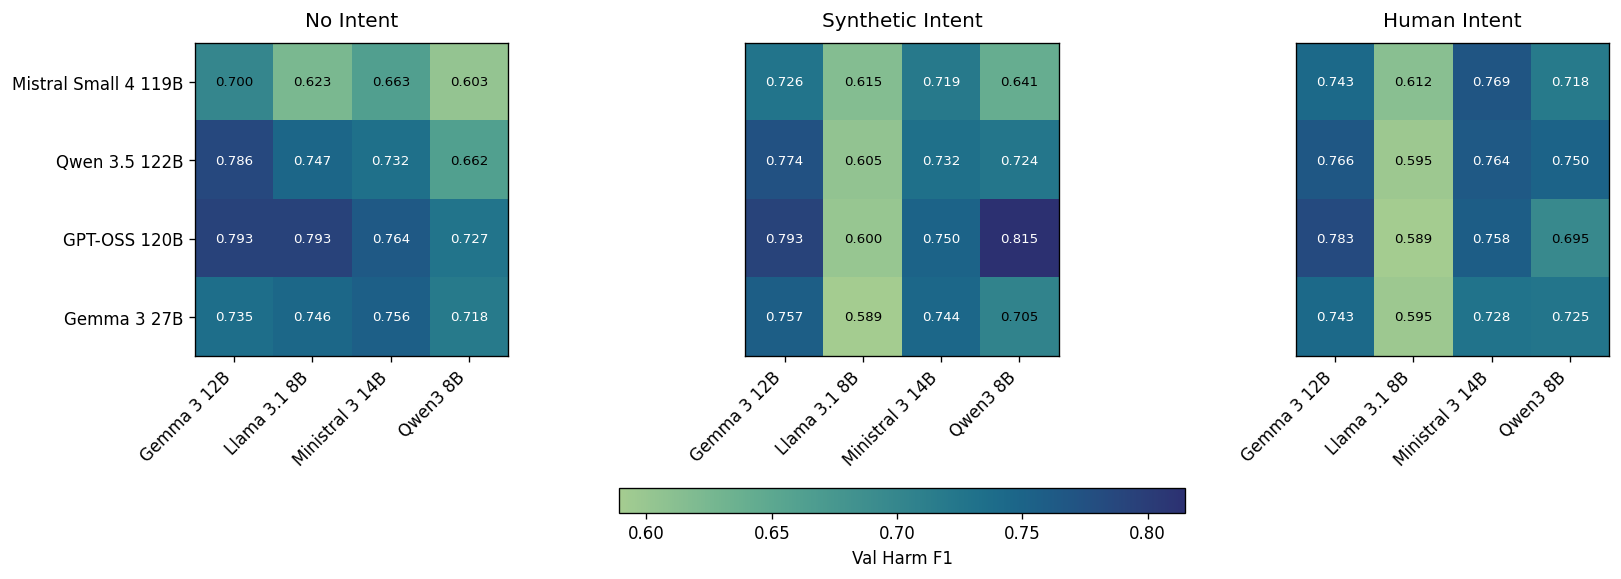

In [2]:
WANDB_ENTITY = "intention-analysis"
WANDB_PROJECT = "Distillation Results"
REFRESH_VAL_F1_CACHE = False  # Set True once to re-fetch val_harm_f1 from W&B; results are cached to disk

_api_summary_index.cache_clear()
load_run_summary.cache_clear()
if REFRESH_VAL_F1_CACHE:
    VAL_F1_CACHE_PATH.unlink(missing_ok=True)
_val_harm_f1_index.cache_clear()

records_df, missing_items = load_combo_rows()

expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
expected_rows = expected_combos * len(DATASETS)

if records_df.empty:
    raise RuntimeError("No distillation results were found.")

combo_df = (
    records_df.groupby(["teacher_slug", "teacher", "student_slug", "student", "condition_slug", "condition", "run_name", "wandb_source"], as_index=False)
    .agg(
        datasets_loaded=("dataset_slug", "nunique"),
        files_loaded=("jsonl_path", "count"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        total_rows=("num_rows", "sum"),
        scored_rows=("num_scored", "sum"),
        val_harm_f1=("val_harm_f1", "first"),
        missing_predictions=("missing_predictions", "sum"),
        total_tokens=("total_tokens", "sum"),
        total_elapsed_s=("wandb_elapsed_s", "sum"),
        wandb_runtime_s=("wandb_runtime_s", "first"),
    )
)
_elapsed_denom = combo_df["total_elapsed_s"].replace(0, np.nan)
combo_df["computed_tokens_per_second"] = combo_df["total_tokens"] / _elapsed_denom

combo_df = combo_df.assign(
    teacher_rank=combo_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=combo_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=combo_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank"])

records_df = records_df.assign(
    teacher_rank=records_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=records_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=records_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
    dataset_rank=records_df["dataset_slug"].map({slug: idx for idx, slug in enumerate(DATASET_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank", "dataset_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank", "dataset_rank"])

print(f"Loaded {len(combo_df)}/{expected_combos} combinations and {len(records_df)}/{expected_rows} dataset files.")
print(f"WandB source counts: {combo_df['wandb_source'].value_counts(dropna=False).to_dict()}")
if missing_items:
    print("Missing items:")
    for item in missing_items:
        print(f"  - {item}")

combo_display = combo_df[[
    "teacher",
    "student",
    "condition",
    "datasets_loaded",
    "mean_accuracy",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "total_tokens",
    "total_elapsed_s",
    "computed_tokens_per_second",
    "wandb_runtime_s",
    "wandb_source",
]]

combo_display = combo_display.rename(columns={
    "mean_accuracy": "accuracy",
    "mean_precision": "precision",
    "mean_recall": "recall",
    "mean_f1": "f1",
    "total_tokens": "tokens",
    "total_elapsed_s": "elapsed_s",
    "computed_tokens_per_second": "tok_per_s",
    "wandb_runtime_s": "wandb_runtime_s",
})

for col in ["accuracy", "precision", "recall", "f1", "tokens", "elapsed_s", "tok_per_s", "wandb_runtime_s"]:
    combo_display[col] = pd.to_numeric(combo_display[col], errors="coerce")

display(
    combo_display.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "tokens": "{:.0f}",
        "elapsed_s": "{:.1f}",
        "tok_per_s": "{:.1f}",
        "wandb_runtime_s": "{:.0f}",
    })
)

print("\nDataset-level details (first 12 rows):")
records_preview = records_df[[
    "teacher",
    "student",
    "condition",
    "dataset",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "num_rows",
    "missing_predictions",
    "wandb_elapsed_s",
    "total_tokens",
    "wandb_tokens_per_second",
]].head(12).copy()

for col in ["accuracy", "precision", "recall", "f1", "wandb_elapsed_s", "total_tokens", "wandb_tokens_per_second"]:
    records_preview[col] = pd.to_numeric(records_preview[col], errors="coerce")

display(
    records_preview.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "wandb_elapsed_s": "{:.1f}",
        "total_tokens": "{:.0f}",
        "wandb_tokens_per_second": "{:.1f}",
    })
)

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "distillation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
axes[1].yaxis.set_visible(False)
axes[2].yaxis.set_visible(False)
heatmap_min = float(combo_df['val_harm_f1'].min())
heatmap_max = float(combo_df['val_harm_f1'].max())
cmap = sns.color_palette("crest", as_cmap=True)
for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        combo_df[combo_df["condition_slug"] == condition_slug]
        .pivot(index="teacher", columns="student", values="val_harm_f1")
        .reindex(index=[TEACHERS[k] for k in TEACHER_ORDER], columns=[STUDENTS[k] for k in STUDENT_ORDER])
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap=cmap)
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            norm_val = (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12)
            text_color = "white" if norm_val > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
# Derive colorbar position from actual axes extents so it stays centred
_p0, _p2 = axes[0].get_position(), axes[2].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation="horizontal", label="Val Harm F1")
fig.savefig(FIGURES_DIR / "distillation_heatmap.pdf", bbox_inches="tight")
plt.show()

## Test Harm F1 — Annotated Intents Dataset

This shows the test F1 scores on the annotated intents dataset for each teacher-student-condition combination.
Selection of best adapters is still based on val_harm_f1 from training, but evaluation results are
reported on the human-annotated test set.


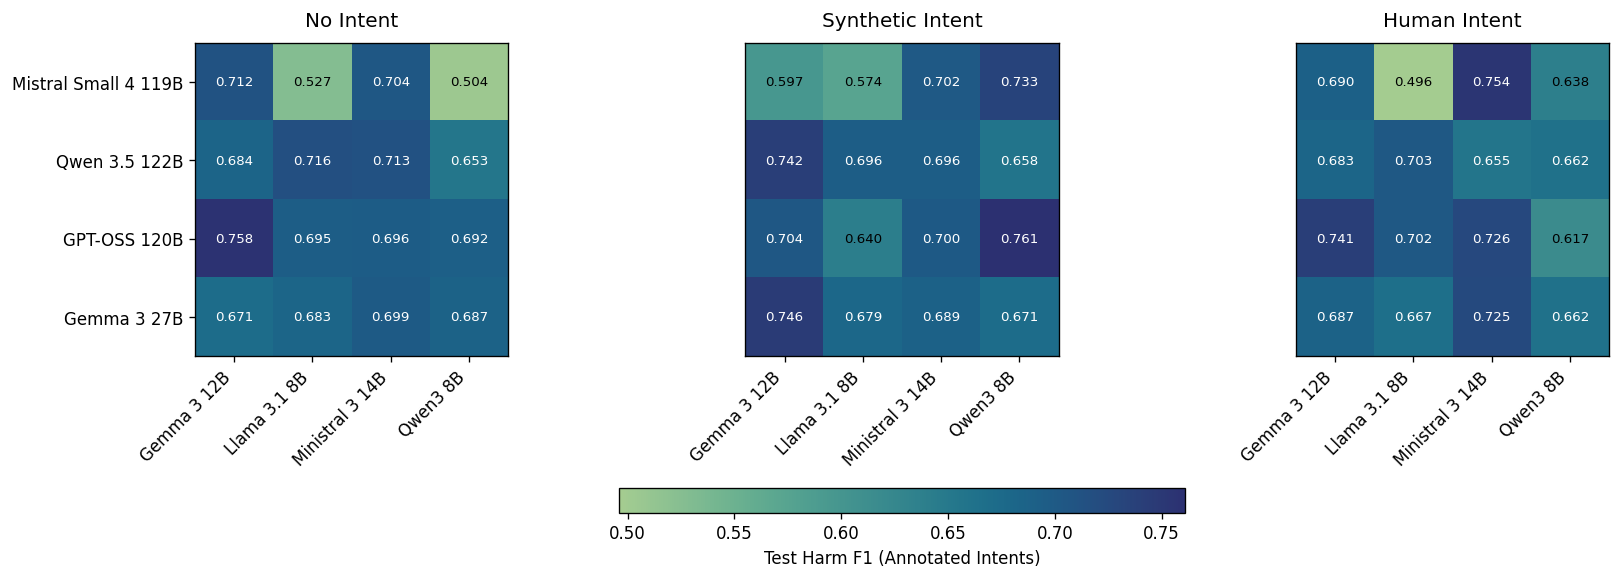

In [3]:
# Extract F1 scores specifically from the annotated_intents dataset
annotated_intents_df = records_df[records_df['dataset_slug'] == 'annotated-intents'].copy()

# Aggregate by teacher, student, condition
test_f1_combo = (
    annotated_intents_df.groupby(
        ['teacher_slug', 'teacher', 'student_slug', 'student', 'condition_slug', 'condition'],
        as_index=False
    )
    .agg(test_f1=('f1', 'first'))
    .sort_values(['teacher_slug', 'student_slug', 'condition_slug'])
)

# Create heatmaps for each condition showing test F1 on annotated intents
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
axes[1].yaxis.set_visible(False)
axes[2].yaxis.set_visible(False)

# Find min/max for consistent colorbar across conditions
test_f1_min = float(test_f1_combo['test_f1'].min())
test_f1_max = float(test_f1_combo['test_f1'].max())
cmap = sns.color_palette('crest', as_cmap=True)

for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        test_f1_combo[test_f1_combo['condition_slug'] == condition_slug]
        .pivot(index='teacher', columns='student', values='test_f1')
        .reindex(
            index=[TEACHERS[k] for k in TEACHER_ORDER],
            columns=[STUDENTS[k] for k in STUDENT_ORDER]
        )
    )
    image = ax.imshow(pivot.values, vmin=test_f1_min, vmax=test_f1_max, cmap=cmap)
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            norm_val = (cell_value - test_f1_min) / (test_f1_max - test_f1_min + 1e-12)
            text_color = 'white' if norm_val > 0.55 else 'black'
            ax.text(j, i, f'{cell_value:.3f}', ha='center', va='center', color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
_p0, _p2 = axes[0].get_position(), axes[2].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation='horizontal', label='Test Harm F1 (Annotated Intents)')
fig.savefig(FIGURES_DIR / 'distillation_test_f1_heatmap.pdf', bbox_inches='tight')
plt.show()


Average tokens per prompt across all datasets and both conditions:


,teacher,student,total_tokens,total_prompts,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
8,Mistral Small 4 119B,Gemma 3 12B,6346497,33147,1927.7,191.5,3292.3
9,Mistral Small 4 119B,Llama 3.1 8B,6747288,33147,1190.7,203.6,5666.7
10,Mistral Small 4 119B,Ministral 3 14B,6098380,33147,1734.9,184.0,3515.2
11,Mistral Small 4 119B,Qwen3 8B,6028876,33147,1283.2,181.9,4698.2
12,Qwen 3.5 122B,Gemma 3 12B,7910637,33147,2297.9,238.7,3442.5
13,Qwen 3.5 122B,Llama 3.1 8B,7791464,33147,1346.5,235.1,5786.5
14,Qwen 3.5 122B,Ministral 3 14B,8285020,33147,2082.3,249.9,3978.7
15,Qwen 3.5 122B,Qwen3 8B,7528011,33147,1406.3,227.1,5352.9
0,GPT-OSS 120B,Gemma 3 12B,4365563,33147,1326.6,131.7,3290.8
1,GPT-OSS 120B,Llama 3.1 8B,4696316,33147,844.6,141.7,5560.3


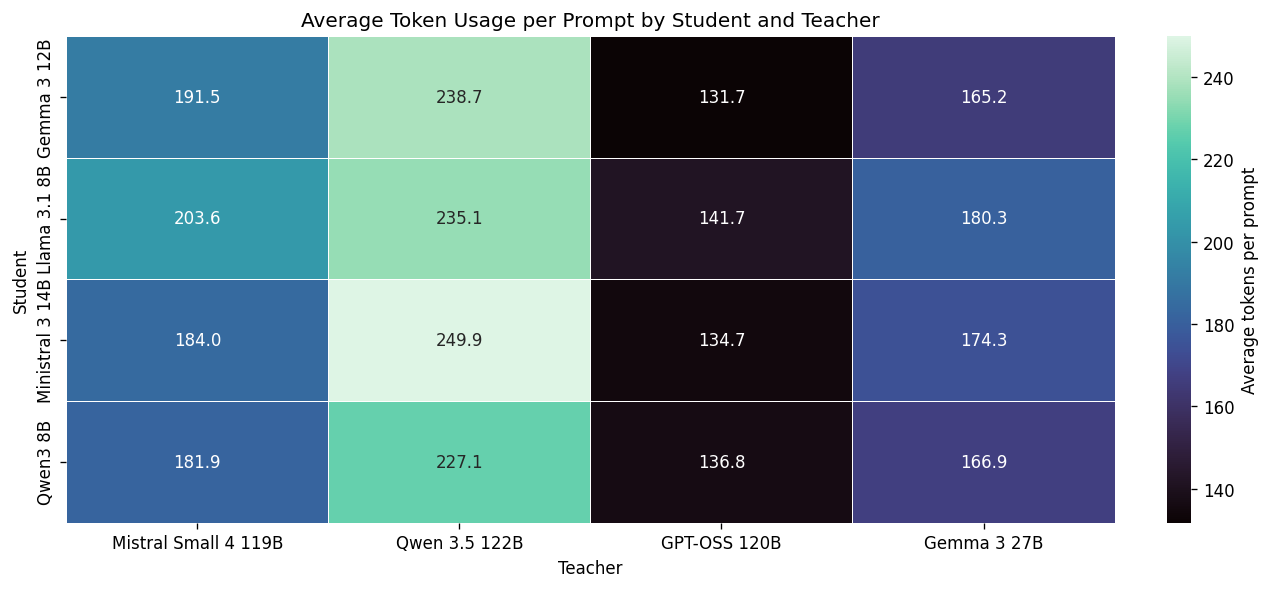


Tokens per second across students (averaged over teachers and intent conditions):


,student,tokens_per_second,total_tokens,total_elapsed_s
0,Gemma 3 12B,3348.9,24098166,7195.9
1,Llama 3.1 8B,5440.2,25209869,4634.0
2,Ministral 3 14B,3645.9,24625904,6754.4
3,Qwen3 8B,4828.1,23621551,4892.5


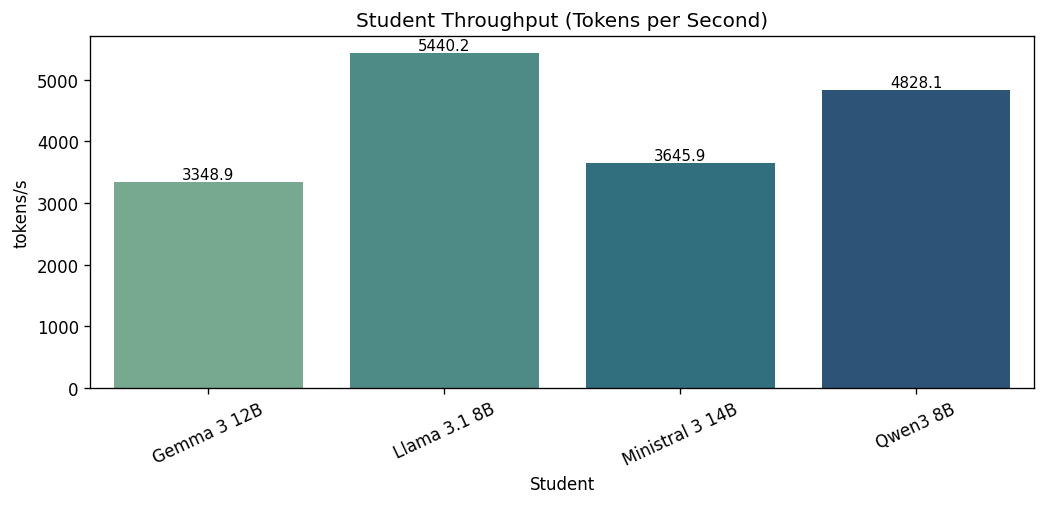


Condition-level token usage (tokens/prompt and tokens/s):


,teacher,student,condition,total_tokens,total_rows,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
36,GPT-OSS 120B,Gemma 3 12B,Human Intent,1550341,11049,480.9,140.3,3223.5
37,GPT-OSS 120B,Gemma 3 12B,No Intent,1248355,11049,364.9,113.0,3421.5
38,GPT-OSS 120B,Gemma 3 12B,Synthetic Intent,1566867,11049,480.8,141.8,3259.0
39,GPT-OSS 120B,Llama 3.1 8B,Human Intent,1670291,11049,299.2,151.2,5582.8
40,GPT-OSS 120B,Llama 3.1 8B,No Intent,1361842,11049,241.0,123.3,5651.4
41,GPT-OSS 120B,Llama 3.1 8B,Synthetic Intent,1664183,11049,304.5,150.6,5466.1
42,GPT-OSS 120B,Ministral 3 14B,Human Intent,1596509,11049,432.4,144.5,3692.5
43,GPT-OSS 120B,Ministral 3 14B,No Intent,1258664,11049,335.1,113.9,3755.7
44,GPT-OSS 120B,Ministral 3 14B,Synthetic Intent,1608750,11049,510.8,145.6,3149.4
45,GPT-OSS 120B,Qwen3 8B,Human Intent,1625551,11049,339.6,147.1,4786.2


In [4]:
# Token usage analysis: average tokens per prompt by student and teacher.

teacher_student_tokens = (
    combo_df.groupby(["teacher", "student"], as_index=False)
    .agg(
        total_tokens=("total_tokens", "sum"),
        total_prompts=("total_rows", "sum"),
        total_elapsed_s=("total_elapsed_s", "sum"),
    )
)
teacher_student_tokens["avg_tokens_per_prompt"] = np.where(
    teacher_student_tokens["total_prompts"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_prompts"],
    np.nan,
)
teacher_student_tokens["avg_tokens_per_second"] = np.where(
    teacher_student_tokens["total_elapsed_s"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_elapsed_s"],
    np.nan,
)

teacher_student_tokens = teacher_student_tokens.assign(
    teacher_rank=lambda df: df["teacher"].map({name: idx for idx, name in enumerate([TEACHERS[k] for k in TEACHER_ORDER])}),
    student_rank=lambda df: df["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])}),
).sort_values(["teacher_rank", "student_rank"]).drop(columns=["teacher_rank", "student_rank"])

print("Average tokens per prompt across all datasets and both conditions:")
display(
    teacher_student_tokens.style.format(
        {
            "total_tokens": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

# Student on rows (index), teacher on columns — student is the primary driver of token count.
pivot_tokens = teacher_student_tokens.pivot(index="student", columns="teacher", values="avg_tokens_per_prompt")
pivot_tokens = pivot_tokens.reindex(index=[STUDENTS[k] for k in STUDENT_ORDER], columns=[TEACHERS[k] for k in TEACHER_ORDER])

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
sns.heatmap(
    pivot_tokens,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Average tokens per prompt"},
    ax=ax,
)
ax.set_title("Average Token Usage per Prompt by Student and Teacher")
ax.set_xlabel("Teacher")
ax.set_ylabel("Student")
plt.show()

# Student-only throughput summary, averaged across all teachers and both intent conditions.
student_tps = (
    combo_df.groupby("student", as_index=False)
    .agg(total_tokens=("total_tokens", "sum"), total_elapsed_s=("total_elapsed_s", "sum"))
)
student_tps["tokens_per_second"] = np.where(
    student_tps["total_elapsed_s"] > 0,
    student_tps["total_tokens"] / student_tps["total_elapsed_s"],
    np.nan,
)
student_tps = student_tps.assign(
    student_rank=student_tps["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])})
).sort_values("student_rank").drop(columns=["student_rank"])

print("\nTokens per second across students (averaged over teachers and intent conditions):")
display(
    student_tps[["student", "tokens_per_second", "total_tokens", "total_elapsed_s"]].style.format(
        {
            "tokens_per_second": "{:.1f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.6, 4.1), constrained_layout=True)
colors = sns.color_palette("crest", n_colors=len(student_tps))
sns.barplot(
    data=student_tps,
    x="student",
    y="tokens_per_second",
    hue="student",
    palette=colors,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Student Throughput (Tokens per Second)")
ax.set_xlabel("Student")
ax.set_ylabel("tokens/s")
ax.tick_params(axis="x", rotation=25)
for bar, value in zip(ax.patches, student_tps["tokens_per_second"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
plt.show()

# Optional condition breakdown for the same normalization.
condition_tokens = combo_df[["teacher", "student", "condition", "total_tokens", "total_rows", "total_elapsed_s"]].copy()
condition_tokens["avg_tokens_per_prompt"] = np.where(
    condition_tokens["total_rows"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_rows"],
    np.nan,
)
condition_tokens["avg_tokens_per_second"] = np.where(
    condition_tokens["total_elapsed_s"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_elapsed_s"],
    np.nan,
)

print("\nCondition-level token usage (tokens/prompt and tokens/s):")
display(
    condition_tokens.sort_values(["teacher", "student", "condition"]).style.format(
        {
            "total_tokens": "{:.0f}",
            "total_rows": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

Condition comparison at the teacher/student level (F1):


condition_slug,teacher,student,no_intent,synthetic_intent,human_intent,synthetic_vs_no_intent,human_vs_synthetic_intent,human_vs_no_intent
12,GPT-OSS 120B,Gemma 3 12B,0.799,0.800,0.805,+0.001,+0.005,+0.006
13,GPT-OSS 120B,Llama 3.1 8B,0.780,0.786,0.793,+0.006,+0.007,+0.014
14,GPT-OSS 120B,Ministral 3 14B,0.766,0.774,0.788,+0.008,+0.014,+0.022
15,GPT-OSS 120B,Qwen3 8B,0.799,0.790,0.771,-0.009,-0.019,-0.028
0,Gemma 3 27B,Gemma 3 12B,0.777,0.786,0.781,+0.009,-0.005,+0.005
1,Gemma 3 27B,Llama 3.1 8B,0.775,0.765,0.770,-0.010,+0.005,-0.005
2,Gemma 3 27B,Ministral 3 14B,0.757,0.762,0.774,+0.005,+0.012,+0.017
3,Gemma 3 27B,Qwen3 8B,0.783,0.774,0.773,-0.009,-0.001,-0.010
4,Mistral Small 4 119B,Gemma 3 12B,0.781,0.762,0.775,-0.018,+0.013,-0.006
5,Mistral Small 4 119B,Llama 3.1 8B,0.749,0.756,0.740,+0.007,-0.016,-0.010


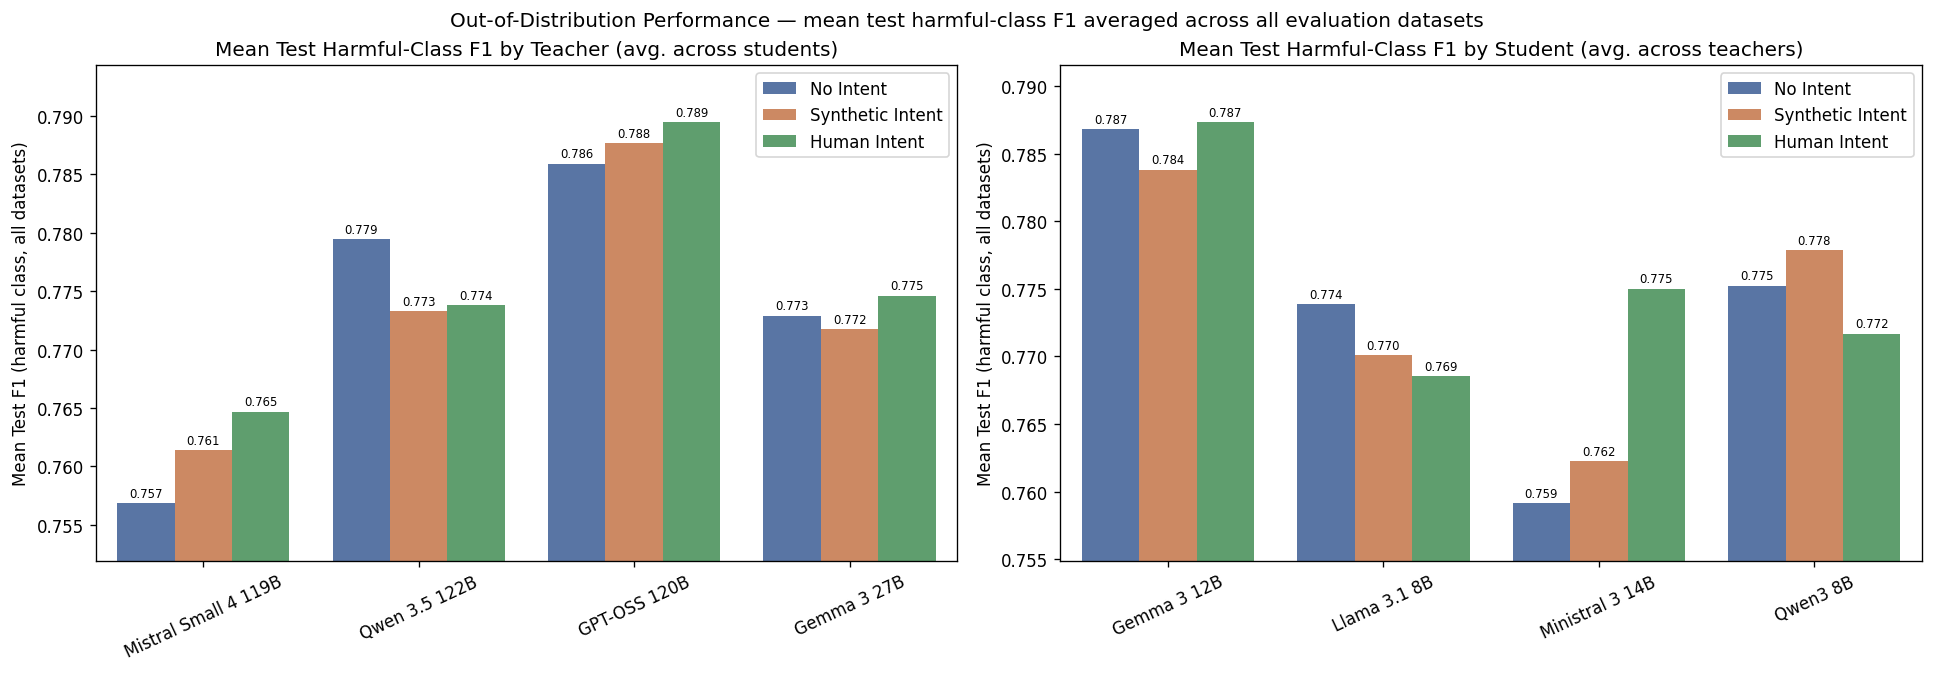

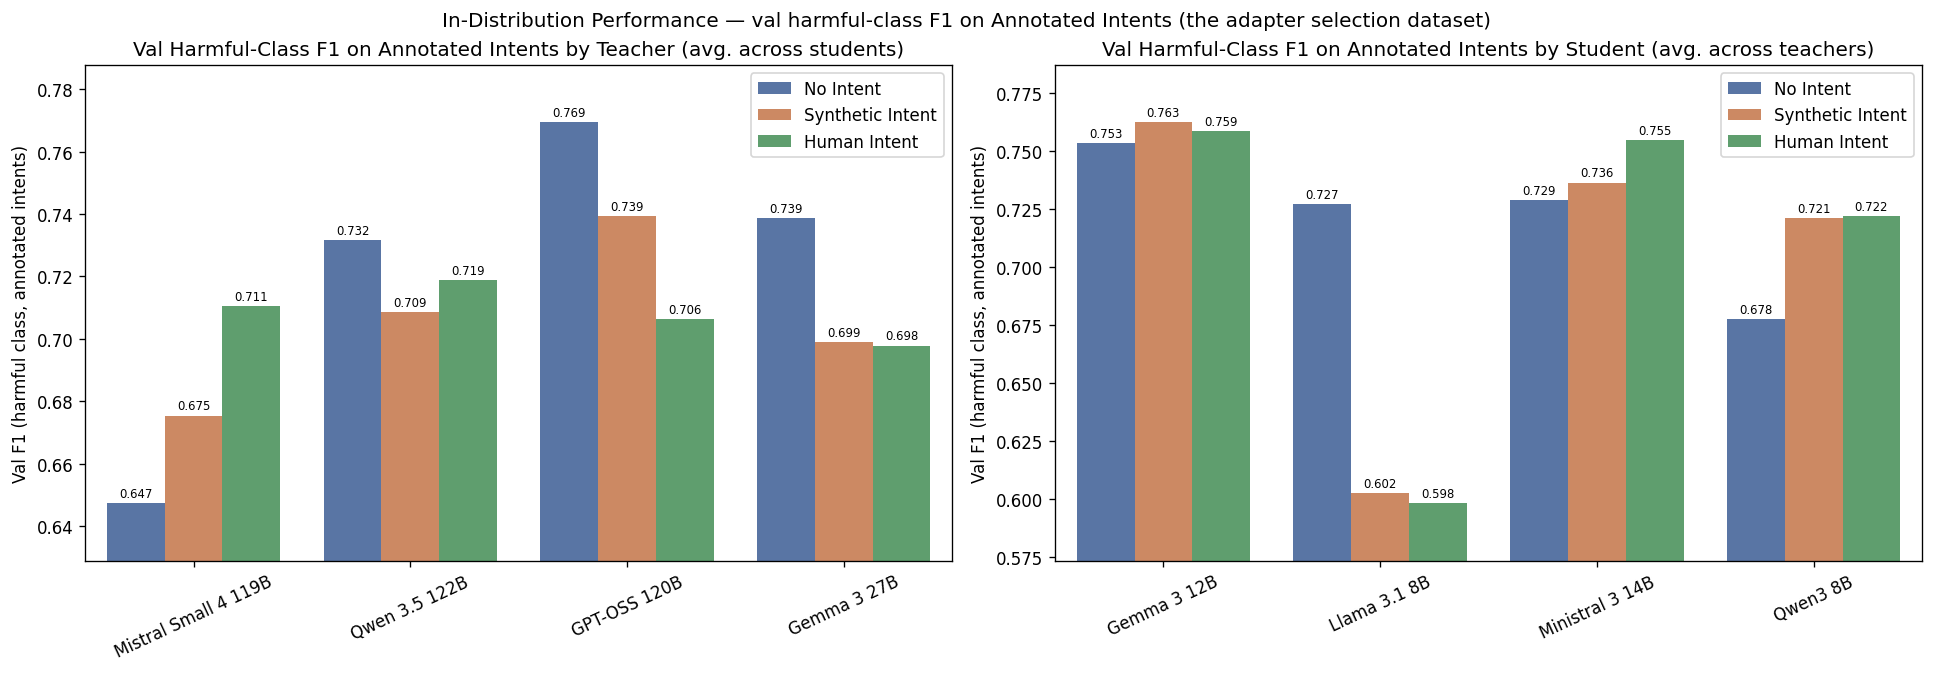

Summary of the intent effect (test F1, all datasets):
  synthetic vs no intent — mean delta: -0.0003
  human vs no intent     — mean delta: +0.0019
  human vs synthetic     — mean delta: +0.0021
  Pairs where human > no intent: 8/16


In [16]:
# Three-way condition comparison: mean F1 per condition (no intent / synthetic intent / human intent).
# Teachers plot: average across students. Students plot: average across teachers.
condition_f1 = (
    combo_df.pivot_table(
        index=["teacher_slug", "teacher", "student_slug", "student"],
        columns="condition_slug",
        values="mean_f1",
        aggfunc="mean",
    )
    .reset_index()
)

# Pairwise deltas (kept for reference table)
condition_f1["synthetic_vs_no_intent"] = condition_f1["synthetic_intent"] - condition_f1["no_intent"]
condition_f1["human_vs_synthetic_intent"] = condition_f1["human_intent"] - condition_f1["synthetic_intent"]
condition_f1["human_vs_no_intent"] = condition_f1["human_intent"] - condition_f1["no_intent"]

pairwise_display = condition_f1[[
    "teacher",
    "student",
    "no_intent",
    "synthetic_intent",
    "human_intent",
    "synthetic_vs_no_intent",
    "human_vs_synthetic_intent",
    "human_vs_no_intent",
]].copy()

print("Condition comparison at the teacher/student level (F1):")
display(
    pairwise_display.sort_values(["teacher", "student"]).style.format({
        "no_intent": "{:.3f}",
        "synthetic_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "synthetic_vs_no_intent": "{:+.3f}",
        "human_vs_synthetic_intent": "{:+.3f}",
        "human_vs_no_intent": "{:+.3f}",
    })
)

# ── Build long-form aggregations for grouped bar charts ───────────────────────
CONDITION_LABEL_MAP = {
    "no_intent": "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent": "Human Intent",
}
CONDITION_LABEL_ORDER = ["No Intent", "Synthetic Intent", "Human Intent"]
CONDITION_PALETTE = dict(zip(CONDITION_LABEL_ORDER, sns.color_palette("deep", 3)))


def _to_long(df, group_col, group_slug_col, order_list, value_col="mean_f1"):
    long = (
        df.groupby([group_slug_col, group_col], as_index=False)
        .agg(
            no_intent=("no_intent", "mean"),
            synthetic_intent=("synthetic_intent", "mean"),
            human_intent=("human_intent", "mean"),
        )
        .melt(
            id_vars=[group_slug_col, group_col],
            value_vars=["no_intent", "synthetic_intent", "human_intent"],
            var_name="condition_slug",
            value_name=value_col,
        )
    )
    long["condition"] = long["condition_slug"].map(CONDITION_LABEL_MAP)
    long["_group_rank"] = long[group_slug_col].map({s: i for i, s in enumerate(order_list)})
    long["_cond_rank"] = long["condition_slug"].map({s: i for i, s in enumerate(CONDITION_ORDER)})
    return long.sort_values(["_group_rank", "_cond_rank"]).drop(columns=["_group_rank", "_cond_rank"])


def _ylim(df, col):
    lo = df[col].min()
    hi = df[col].max()
    padding = (hi - lo) * 0.15 if hi > lo else 0.05
    return max(0.0, lo - padding), min(1.0, hi + padding)


teacher_long = _to_long(condition_f1, "teacher", "teacher_slug", TEACHER_ORDER)
student_long = _to_long(condition_f1, "student", "student_slug", STUDENT_ORDER)

# ── Out-of-distribution: mean test harmful-class F1 across all evaluation datasets ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

for ax, df, label_col, order_slugs, slug_to_name, other_dim in [
    (axes[0], teacher_long, "teacher", TEACHER_ORDER, TEACHERS, "students"),
    (axes[1], student_long, "student", STUDENT_ORDER, STUDENTS, "teachers"),
]:
    x_order = [slug_to_name[s] for s in order_slugs if slug_to_name.get(s) in df[label_col].values]
    sns.barplot(
        data=df,
        x=label_col,
        y="mean_f1",
        hue="condition",
        hue_order=CONDITION_LABEL_ORDER,
        order=x_order,
        palette=CONDITION_PALETTE,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(f"Mean Test Harmful-Class F1 by {label_col.title()} (avg. across {other_dim})")
    ax.set_ylabel("Mean Test F1 (harmful class, all datasets)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(*_ylim(df, "mean_f1"))
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{bar.get_height():.3f}" for bar in container],
            padding=2,
            fontsize=7,
        )
    ax.legend(title=None, loc="upper right")

fig.suptitle("Out-of-Distribution Performance — mean test harmful-class F1 averaged across all evaluation datasets", fontsize=12)
plt.show()

# ── In-distribution: val harmful-class F1 on annotated intents (adapter selection set) ─
condition_val_f1 = (
    combo_df.pivot_table(
        index=["teacher_slug", "teacher", "student_slug", "student"],
        columns="condition_slug",
        values="val_harm_f1",
        aggfunc="mean",
    )
    .reset_index()
)

teacher_val_long = _to_long(condition_val_f1, "teacher", "teacher_slug", TEACHER_ORDER, value_col="val_harm_f1")
student_val_long = _to_long(condition_val_f1, "student", "student_slug", STUDENT_ORDER, value_col="val_harm_f1")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

for ax, df, label_col, order_slugs, slug_to_name, other_dim in [
    (axes[0], teacher_val_long, "teacher", TEACHER_ORDER, TEACHERS, "students"),
    (axes[1], student_val_long, "student", STUDENT_ORDER, STUDENTS, "teachers"),
]:
    x_order = [slug_to_name[s] for s in order_slugs if slug_to_name.get(s) in df[label_col].values]
    sns.barplot(
        data=df,
        x=label_col,
        y="val_harm_f1",
        hue="condition",
        hue_order=CONDITION_LABEL_ORDER,
        order=x_order,
        palette=CONDITION_PALETTE,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(f"Val Harmful-Class F1 on Annotated Intents by {label_col.title()} (avg. across {other_dim})")
    ax.set_ylabel("Val F1 (harmful class, annotated intents)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(*_ylim(df, "val_harm_f1"))
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{bar.get_height():.3f}" for bar in container],
            padding=2,
            fontsize=7,
        )
    ax.legend(title=None, loc="upper right")

fig.suptitle("In-Distribution Performance — val harmful-class F1 on Annotated Intents (the adapter selection dataset)", fontsize=12)
plt.show()

print("Summary of the intent effect (test F1, all datasets):")
print(f"  synthetic vs no intent — mean delta: {condition_f1['synthetic_vs_no_intent'].mean():+.4f}")
print(f"  human vs no intent     — mean delta: {condition_f1['human_vs_no_intent'].mean():+.4f}")
print(f"  human vs synthetic     — mean delta: {condition_f1['human_vs_synthetic_intent'].mean():+.4f}")
print(f"  Pairs where human > no intent: {(condition_f1['human_vs_no_intent'] > 0).sum()}/{len(condition_f1)}")

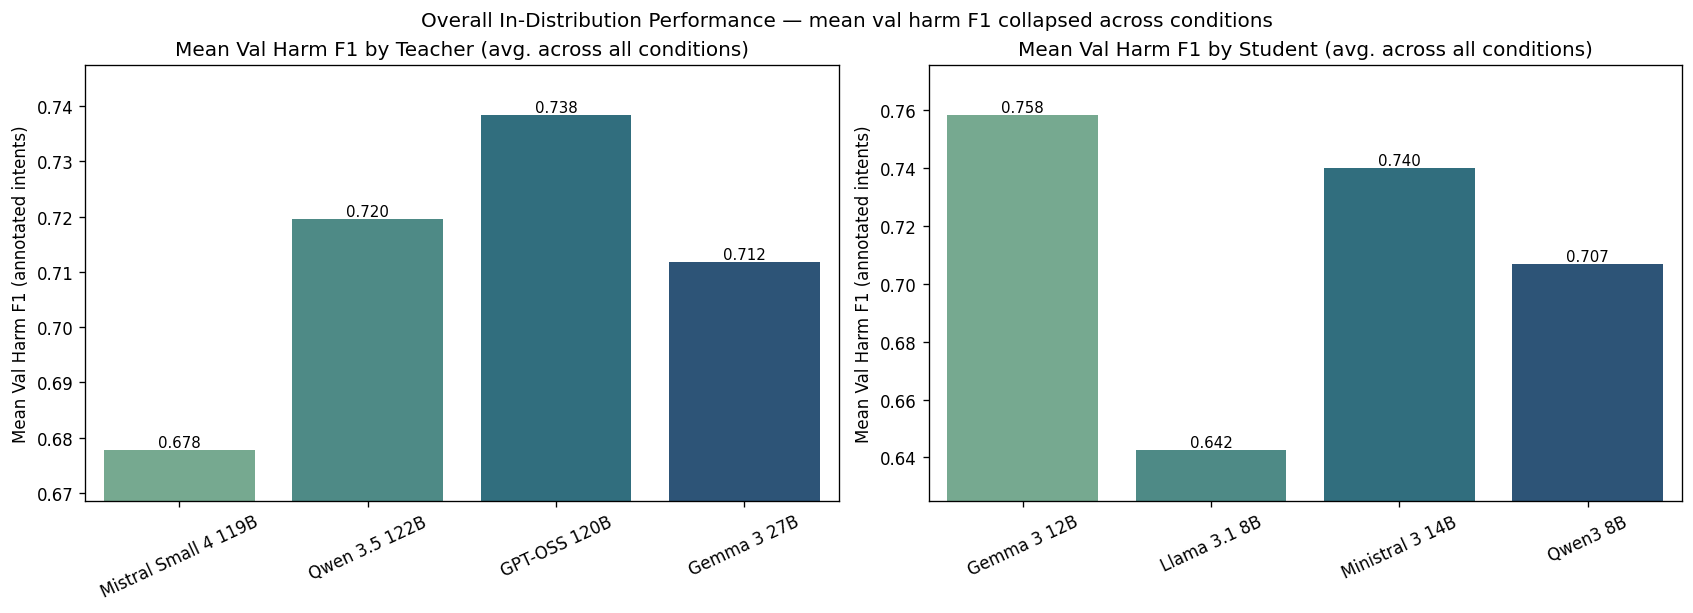

Mean val harm F1 by teacher (across all conditions and students):


,teacher,val_harm_f1
1,Mistral Small 4 119B,0.678
2,Qwen 3.5 122B,0.720
3,GPT-OSS 120B,0.738
0,Gemma 3 27B,0.712



Mean val harm F1 by student (across all conditions and teachers):


,student,val_harm_f1
0,Gemma 3 12B,0.758
1,Llama 3.1 8B,0.642
2,Ministral 3 14B,0.740
3,Qwen3 8B,0.707


In [19]:
# Mean val harm F1 by teacher and by student, averaged across all 3 conditions.
# Complements the condition-breakdown plots above by showing the overall ranking
# of each teacher/student regardless of which condition was used.

val_by_teacher = (
    combo_df.groupby(["teacher_slug", "teacher"], as_index=False)["val_harm_f1"]
    .mean()
    .assign(teacher_rank=lambda df: df["teacher_slug"].map({s: i for i, s in enumerate(TEACHER_ORDER)}))
    .sort_values("teacher_rank")
    .drop(columns="teacher_rank")
)

val_by_student = (
    combo_df.groupby(["student_slug", "student"], as_index=False)["val_harm_f1"]
    .mean()
    .assign(student_rank=lambda df: df["student_slug"].map({s: i for i, s in enumerate(STUDENT_ORDER)}))
    .sort_values("student_rank")
    .drop(columns="student_rank")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, df, label_col, slug_col, order in [
    (axes[0], val_by_teacher, "teacher", "teacher_slug", TEACHER_ORDER),
    (axes[1], val_by_student, "student", "student_slug", STUDENT_ORDER),
]:
    x_order = [TEACHERS[s] if label_col == "teacher" else STUDENTS[s] for s in order if s in df[slug_col].values]
    colors = sns.color_palette("crest", n_colors=len(x_order))
    sns.barplot(
        data=df,
        x=label_col,
        y="val_harm_f1",
        order=x_order,
        palette=colors,
        hue=label_col,
        legend=False,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(f"Mean Val Harm F1 by {label_col.title()} (avg. across all conditions)")
    ax.set_ylabel("Mean Val Harm F1 (annotated intents)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    lo = df["val_harm_f1"].min()
    hi = df["val_harm_f1"].max()
    pad = (hi - lo) * 0.15 if hi > lo else 0.05
    ax.set_ylim(max(0.0, lo - pad), min(1.0, hi + pad))
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9,
        )

fig.suptitle("Overall In-Distribution Performance — mean val harm F1 collapsed across conditions", fontsize=12)
plt.show()

print("Mean val harm F1 by teacher (across all conditions and students):")
display(val_by_teacher[["teacher", "val_harm_f1"]].style.format({"val_harm_f1": "{:.3f}"}))
print("\nMean val harm F1 by student (across all conditions and teachers):")
display(val_by_student[["student", "val_harm_f1"]].style.format({"val_harm_f1": "{:.3f}"}))

condition_slug,dataset,no_intent,synthetic_intent,human_intent,synthetic_vs_no_intent,human_vs_synthetic_intent,human_vs_no_intent
4,WildGuardMix,0.844,0.842,0.853,-0.002,+0.011,+0.009
3,Toxic Chat,0.654,0.649,0.659,-0.005,+0.010,+0.005
5,XSTest,0.893,0.885,0.897,-0.008,+0.012,+0.004
1,Annotated Intents,0.675,0.687,0.676,+0.012,-0.011,+0.001
2,OpenAI Moderation,0.760,0.761,0.760,+0.001,-0.002,-0.001
0,Aegis,0.816,0.817,0.809,+0.001,-0.008,-0.007


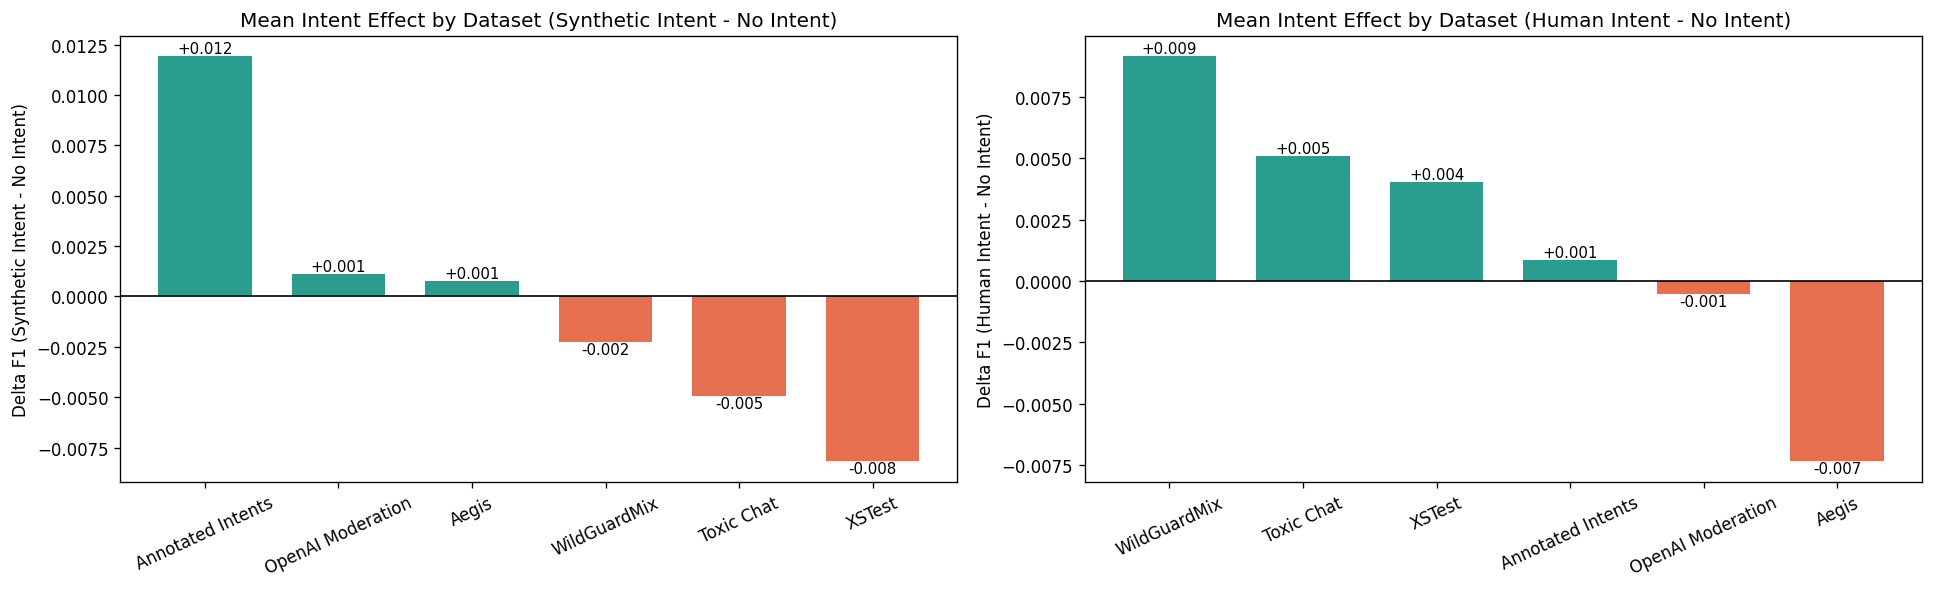

Dataset-level intent effect summary:
  synthetic vs no intent — mean delta: -0.0003, datasets positive: 3/6
  human vs no intent — mean delta: +0.0019, datasets positive: 4/6

Best and worst datasets by human vs no intent delta:


condition_slug,dataset,no_intent,synthetic_intent,human_intent,synthetic_vs_no_intent,human_vs_synthetic_intent,human_vs_no_intent,rank
0,WildGuardMix,0.844,0.842,0.853,-0.002,0.011378,+0.009,top
1,Toxic Chat,0.654,0.649,0.659,-0.005,0.010037,+0.005,top
2,XSTest,0.893,0.885,0.897,-0.008,0.012192,+0.004,top
3,Aegis,0.816,0.817,0.809,+0.001,-0.008094,-0.007,bottom
4,OpenAI Moderation,0.760,0.761,0.760,+0.001,-0.001682,-0.001,bottom
5,Annotated Intents,0.675,0.687,0.676,+0.012,-0.011055,+0.001,bottom


In [18]:
dataset_f1 = (
    records_df.pivot_table(
        index=["dataset_slug", "dataset"],
        columns="condition_slug",
        values="f1",
        aggfunc="mean",
    )
    .reset_index()
)

dataset_f1["synthetic_vs_no_intent"] = dataset_f1["synthetic_intent"] - dataset_f1["no_intent"]
dataset_f1["human_vs_synthetic_intent"] = dataset_f1["human_intent"] - dataset_f1["synthetic_intent"]
dataset_f1["human_vs_no_intent"] = dataset_f1["human_intent"] - dataset_f1["no_intent"]

dataset_display = dataset_f1[[
    "dataset",
    "no_intent",
    "synthetic_intent",
    "human_intent",
    "synthetic_vs_no_intent",
    "human_vs_synthetic_intent",
    "human_vs_no_intent",
]].copy()

dataset_display = dataset_display.sort_values("human_vs_no_intent", ascending=False)

display(
    dataset_display.style.format({
        "no_intent": "{:.3f}",
        "synthetic_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "synthetic_vs_no_intent": "{:+.3f}",
        "human_vs_synthetic_intent": "{:+.3f}",
        "human_vs_no_intent": "{:+.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), constrained_layout=True)

for ax, delta_col, title, ylabel in [
    (axes[0], "synthetic_vs_no_intent", "Mean Intent Effect by Dataset (Synthetic Intent - No Intent)", "Delta F1 (Synthetic Intent - No Intent)"),
    (axes[1], "human_vs_no_intent",     "Mean Intent Effect by Dataset (Human Intent - No Intent)",    "Delta F1 (Human Intent - No Intent)"),
]:
    sorted_df = dataset_display.sort_values(delta_col, ascending=False)
    colors = ["#2A9D8F" if v >= 0 else "#E76F51" for v in sorted_df[delta_col]]
    ax.bar(sorted_df["dataset"], sorted_df[delta_col], color=colors, width=0.7)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    for x_pos, value in enumerate(sorted_df[delta_col]):
        ax.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

plt.show()

print("Dataset-level intent effect summary:")
for label, col in [("synthetic vs no intent", "synthetic_vs_no_intent"), ("human vs no intent", "human_vs_no_intent")]:
    print(f"  {label} — mean delta: {dataset_f1[col].mean():+.4f}, datasets positive: {(dataset_f1[col] > 0).sum()}/{len(dataset_f1)}")

print("\nBest and worst datasets by human vs no intent delta:")
display(
    pd.concat(
        [
            dataset_display.head(3).assign(rank="top"),
            dataset_display.tail(3).sort_values("human_vs_no_intent").assign(rank="bottom"),
        ],
        ignore_index=True,
    ).style.format({
        "no_intent": "{:.3f}",
        "synthetic_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "synthetic_vs_no_intent": "{:+.3f}",
        "human_vs_no_intent": "{:+.3f}",
    })
)

Best student (by mean val harm F1 across teachers/conditions): Gemma 3 12B (gemma-3-12b)
Best teacher (by mean val harm F1 across students/conditions): GPT-OSS 120B (openai-gpt-oss-120b)
Selected condition (highest val_harm_f1 for that pair):        Synthetic Intent  (val=0.793)


,Best distillation,WildGuard
Average,0.819,0.804
Aegis,0.817,0.809
OpenAI Moderation,0.796,0.724
Toxic Chat,0.681,0.652
WildGuardMix,0.879,0.888
XSTest,0.923,0.945


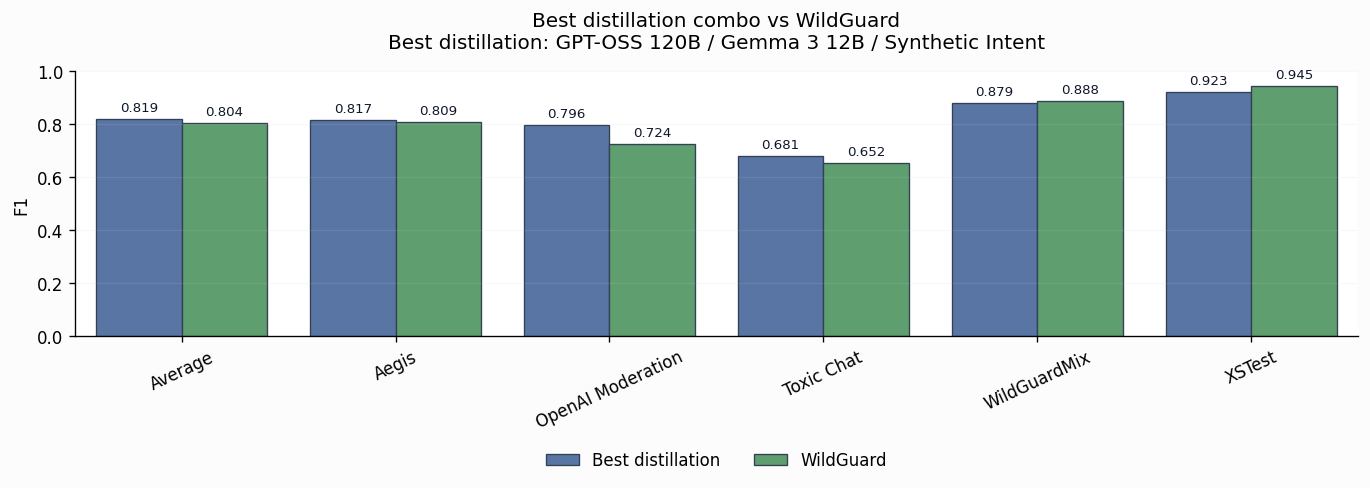

Best combo selected: teacher=GPT-OSS 120B, student=Gemma 3 12B, condition=Synthetic Intent, mean_f1=0.8000
Distillation average across datasets: 0.8192
WildGuard average across datasets: 0.8038


In [28]:
# Best overall result: compare the top distillation combo against WildGuard across datasets.

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_metrics(results: list[dict]) -> dict:
    tp = fp = tn = fn = 0
    for record in results:
        true_harm = record.get("true_harm_binary") or record.get("true_harm")
        pred_harm = record.get("predicted_harm")
        if true_harm is None or pred_harm is None:
            continue
        true_lower = str(true_harm).lower()
        pred_lower = str(pred_harm).lower()
        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1
    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": (tp + tn) / total if total else 0.0, "precision": precision, "recall": recall, "f1": f1}


# Select best student: highest mean val_harm_f1 averaged across all teachers and conditions.
best_student_slug = combo_df.groupby("student_slug")["val_harm_f1"].mean().idxmax()

# Select best teacher: highest mean val_harm_f1 averaged across all students and conditions.
best_teacher_slug = combo_df.groupby("teacher_slug")["val_harm_f1"].mean().idxmax()

# Among combos matching both, pick highest val_harm_f1; ties resolve to the last row in combo_df.
_candidates = combo_df[
    (combo_df["student_slug"] == best_student_slug) &
    (combo_df["teacher_slug"] == best_teacher_slug)
]
_max_val = _candidates["val_harm_f1"].round(3).max()
best_combo = _candidates[_candidates["val_harm_f1"].round(3) == _max_val].iloc[-1]

best_teacher = best_combo["teacher"]
best_student = best_combo["student"]
best_condition = best_combo["condition"]
best_score = float(best_combo["mean_f1"])

print(f"Best student (by mean val harm F1 across teachers/conditions): {best_student} ({best_student_slug})")
print(f"Best teacher (by mean val harm F1 across students/conditions): {best_teacher} ({best_teacher_slug})")
print(f"Selected condition (highest val_harm_f1 for that pair):        {best_condition}  (val={float(_max_val):.3f})")

best_records = records_df[
    (records_df["teacher"] == best_teacher)
    & (records_df["student"] == best_student)
    & (records_df["condition"] == best_condition)
].copy()

best_summary = (
    best_records.groupby("dataset", as_index=False)["f1"]
    .mean()
    .rename(columns={"dataset": "dataset", "f1": "f1"})
    .query("dataset != 'Annotated Intents'")
    .sort_values("dataset")
    .reset_index(drop=True)
)

safety_results_root = PROJECT_ROOT / "data/safety_experiment"
wildguard_paths = {
    "Aegis": safety_results_root / "aegis" / "allenai_wildguard_wildguard_classification.jsonl",
    "OpenAI Moderation": safety_results_root / "openai-moderation" / "allenai_wildguard_wildguard_classification.jsonl",
    "Toxic Chat": safety_results_root / "toxic-chat" / "allenai_wildguard_wildguard_classification.jsonl",
    "WildGuardMix": safety_results_root / "wildguardmix" / "allenai_wildguard_wildguard_classification.jsonl",
    "XSTest": safety_results_root / "xstest" / "allenai_wildguard_wildguard_classification.jsonl",
}

wildguard_rows = []
for dataset, path in wildguard_paths.items():
    wildguard_rows.append({"dataset": dataset, "model": "WildGuard", **compute_metrics(load_jsonl(path))})

wildguard_summary = pd.DataFrame(wildguard_rows)[["dataset", "model", "f1"]]

comparison_df = pd.concat(
    [
        best_summary.assign(model="Best distillation"),
        wildguard_summary,
    ],
    ignore_index=True,
 )

average_df = comparison_df.groupby("model", as_index=False)["f1"].mean().assign(dataset="Average")
comparison_df = pd.concat([comparison_df, average_df], ignore_index=True)

dataset_order = ["Average"] + sorted(d for d in comparison_df["dataset"].unique() if d != "Average")
model_order = ["Best distillation", "WildGuard"]
comparison_df["dataset"] = pd.Categorical(comparison_df["dataset"], categories=dataset_order, ordered=True)
comparison_df["model"] = pd.Categorical(comparison_df["model"], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

display(comparison_df.pivot(index="dataset", columns="model", values="f1").reindex(dataset_order).rename_axis(index=None, columns=None).style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(13.8, 5.8))
fig.patch.set_facecolor("#fcfcfc")
ax.set_facecolor("white")
palette = {"Best distillation": sns.color_palette("deep")[0], "WildGuard": sns.color_palette("deep")[2]}

sns.barplot(
    data=comparison_df,
    x="dataset",
    y="f1",
    hue="model",
    order=dataset_order,
    hue_order=model_order,
    palette=palette,
    ax=ax,
    edgecolor="#334155",
    linewidth=0.8,
    errorbar=None,
)

ax.set_title(
    f"Best distillation combo vs WildGuard\n"
    f"Best distillation: {best_teacher} / {best_student} / {best_condition}",
    pad=14,
)
ax.set_xlabel("")
ax.xaxis.label.set_visible(False)
ax.set_ylabel("F1")
ax.set_ylim(0, min(1.0, max(comparison_df["f1"].max() * 1.12, 0.05)))
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.grid(axis="y", color="#cbd5e1", alpha=0.12, linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.3f}" for bar in container], padding=3, fontsize=8, color="#0f172a")

ax.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, frameon=False)
sns.despine(ax=ax, left=False, bottom=False)
fig.subplots_adjust(bottom=0.50)
plt.show()

print(f"Best combo selected: teacher={best_teacher}, student={best_student}, condition={best_condition}, mean_f1={best_score:.4f}")
print(f"Distillation average across datasets: {comparison_df[comparison_df['model'] == 'Best distillation']['f1'].mean():.4f}")
print(f"WildGuard average across datasets: {comparison_df[comparison_df['model'] == 'WildGuard']['f1'].mean():.4f}")

Efficiency comparison on overlapping datasets: aegis, annotated-intents, openai-moderation, toxic-chat, wildguardmix, xstest
WildGuard metrics source: artifact:intention-analysis/Baselines/safety-experiment-baselines:latest (run=pbr3ykej)


,model,details,datasets_compared,total_prompts,total_tokens,total_elapsed_s,tokens_per_prompt,seconds_per_prompt,tokens_per_second
0,Best distillation,GPT-OSS 120B / Qwen3 8B / Synthetic Intent,6,11049,1636401,340.9,148.1,0.0309,4800.0
1,WildGuard,condition=wildguard_classification,6,11047,254542,72.2,23.0,0.0065,3524.6


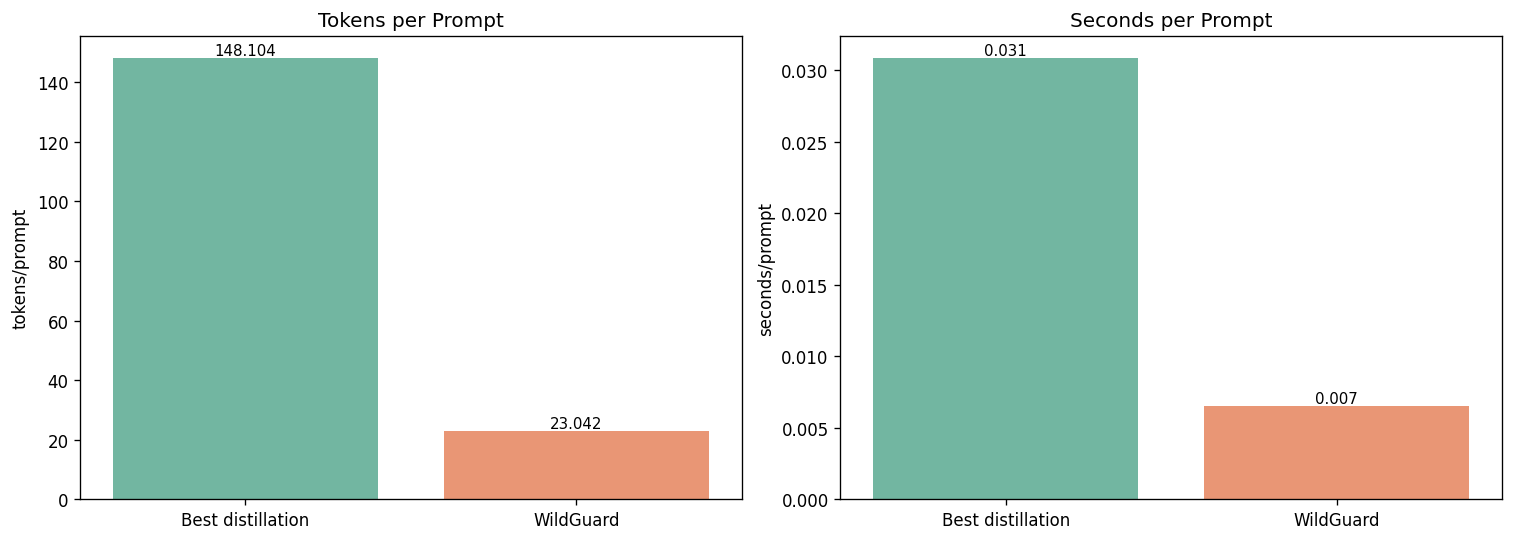

In [8]:
# Efficiency comparison: WildGuard baseline vs best distillation combo

api = wandb.Api()


def _dataset_aliases(slug: str) -> set[str]:
    aliases = {slug, slug.replace("-", "_")}
    if slug == "annotated-intents":
        aliases.add("annotated_intents")
    if slug == "toxic-chat":
        aliases.add("toxic_chat")
    return aliases


def _extract_dataset_condition_metrics(summary: dict) -> pd.DataFrame:
    rows = []
    patterns = [
        re.compile(r"^([^/]+)/([^/]+)/total_tokens$"),
        re.compile(r"^([^/]+)/([^/]+)/elapsed_s$"),
        re.compile(r"^([^/]+)/([^/]+)/total$"),
    ]

    grouped = {}
    for key, value in summary.items():
        if not isinstance(key, str):
            continue
        for pattern in patterns:
            match = pattern.match(key)
            if not match:
                continue
            dataset_raw, condition = match.group(1), match.group(2)
            metric_name = key.rsplit("/", 1)[-1]
            grouped.setdefault((dataset_raw, condition), {})[metric_name] = value
            break

    canonical = {}
    alias_to_canonical = {}
    for dataset_slug in DATASETS.keys():
        for alias in _dataset_aliases(dataset_slug):
            alias_to_canonical[alias] = dataset_slug

    for (dataset_raw, condition), metrics in grouped.items():
        dataset_slug = alias_to_canonical.get(dataset_raw)
        if dataset_slug is None:
            continue
        canonical.setdefault((dataset_slug, condition), {}).update(metrics)

    for (dataset_slug, condition), metrics in canonical.items():
        rows.append(
            {
                "dataset_slug": dataset_slug,
                "condition": condition,
                "total_tokens": pd.to_numeric(metrics.get("total_tokens"), errors="coerce"),
                "elapsed_s": pd.to_numeric(metrics.get("elapsed_s"), errors="coerce"),
                "total_prompts": pd.to_numeric(metrics.get("total"), errors="coerce"),
            }
        )

    return pd.DataFrame(rows)


def _get_wildguard_summary_from_artifact() -> tuple[dict, str]:
    artifact_candidates = [
        "intention-analysis/Baselines/safety-experiment-baselines:latest",
        "Jazhyc/Baselines/safety-experiment-baselines:latest",
    ]

    for artifact_ref in artifact_candidates:
        try:
            artifact = api.artifact(artifact_ref)
            run = artifact.logged_by()
            if run is not None:
                return dict(run.summary), f"artifact:{artifact_ref} (run={run.id})"
        except Exception:
            continue

    run_candidates = [
        "intention-analysis/Baselines",
        "Jazhyc/Baselines",
    ]
    for path in run_candidates:
        try:
            runs = api.runs(path=path, per_page=200)
        except Exception:
            continue

        for run in runs:
            summary = dict(run.summary)
            has_tokens = any(isinstance(k, str) and k.endswith("/total_tokens") for k in summary.keys())
            has_wildguard = (
                "wildguard" in (getattr(run, "display_name", "") or "").lower()
                or "wildguard" in (getattr(run, "name", "") or "").lower()
                or any("wildguard" in str(k).lower() for k in summary.keys())
            )
            if has_tokens and has_wildguard:
                return summary, f"run:{path}/{run.id}"

    raise RuntimeError("Could not locate WildGuard baseline summary in artifacts or Baselines runs.")


# 1) Best distillation aggregate from existing combo_df
best_combo_row = combo_df.sort_values("val_harm_f1", ascending=False).iloc[0]
best_teacher_name = best_combo_row["teacher"]
best_student_name = best_combo_row["student"]
best_condition_name = best_combo_row["condition"]

best_records_eff = records_df[
    (records_df["teacher"] == best_teacher_name)
    & (records_df["student"] == best_student_name)
    & (records_df["condition"] == best_condition_name)
].copy()

# 2) WildGuard metrics from WandB artifact/run summary
wildguard_summary, wildguard_source = _get_wildguard_summary_from_artifact()
wildguard_metrics = _extract_dataset_condition_metrics(wildguard_summary)

if wildguard_metrics.empty:
    raise RuntimeError("Found WildGuard summary source but no dataset-level token/elapsed metrics were parseable.")

# Prefer a condition containing 'wildguard'; otherwise use condition with max dataset coverage.
coverage = (
    wildguard_metrics.groupby("condition", as_index=False)
    .agg(datasets=("dataset_slug", "nunique"))
    .sort_values(["datasets", "condition"], ascending=[False, True])
)
preferred = coverage[coverage["condition"].str.contains("wildguard", case=False, regex=False)]
if not preferred.empty:
    wildguard_condition = preferred.iloc[0]["condition"]
else:
    wildguard_condition = coverage.iloc[0]["condition"]

wildguard_selected = wildguard_metrics[wildguard_metrics["condition"] == wildguard_condition].copy()

# Compare on overlapping datasets for fairness.
common_datasets = sorted(set(best_records_eff["dataset_slug"]).intersection(set(wildguard_selected["dataset_slug"])))
if not common_datasets:
    raise RuntimeError("No overlapping datasets found between best distillation records and WildGuard summary metrics.")

best_overlap = best_records_eff[best_records_eff["dataset_slug"].isin(common_datasets)].copy()
wildguard_overlap = wildguard_selected[wildguard_selected["dataset_slug"].isin(common_datasets)].copy()

best_total_tokens = pd.to_numeric(best_overlap["total_tokens"], errors="coerce").sum()
best_total_elapsed = pd.to_numeric(best_overlap["wandb_elapsed_s"], errors="coerce").sum()
best_total_elapsed = best_total_elapsed if best_total_elapsed > 0 else float("nan")
best_total_prompts = pd.to_numeric(best_overlap["num_rows"], errors="coerce").sum()

wg_total_tokens = pd.to_numeric(wildguard_overlap["total_tokens"], errors="coerce").sum()
wg_total_elapsed = pd.to_numeric(wildguard_overlap["elapsed_s"], errors="coerce").sum()
wg_total_prompts = pd.to_numeric(wildguard_overlap["total_prompts"], errors="coerce").sum()

comparison_efficiency = pd.DataFrame(
    [
        {
            "model": "Best distillation",
            "details": f"{best_teacher_name} / {best_student_name} / {best_condition_name}",
            "datasets_compared": len(common_datasets),
            "total_prompts": best_total_prompts,
            "total_tokens": best_total_tokens,
            "total_elapsed_s": best_total_elapsed,
        },
        {
            "model": "WildGuard",
            "details": f"condition={wildguard_condition}",
            "datasets_compared": len(common_datasets),
            "total_prompts": wg_total_prompts,
            "total_tokens": wg_total_tokens,
            "total_elapsed_s": wg_total_elapsed,
        },
    ]
)

comparison_efficiency["tokens_per_prompt"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_prompts"]
comparison_efficiency["seconds_per_prompt"] = comparison_efficiency["total_elapsed_s"] / comparison_efficiency["total_prompts"]
comparison_efficiency["tokens_per_second"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_elapsed_s"]

print("Efficiency comparison on overlapping datasets:", ", ".join(common_datasets))
print("WildGuard metrics source:", wildguard_source)

display(
    comparison_efficiency.style.format(
        {
            "datasets_compared": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "tokens_per_prompt": "{:.1f}",
            "seconds_per_prompt": "{:.4f}",
            "tokens_per_second": "{:.1f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)
sns.barplot(data=comparison_efficiency, x="model", y="tokens_per_prompt", hue="model", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Tokens per Prompt")
axes[0].set_ylabel("tokens/prompt")
axes[0].set_xlabel("")

sns.barplot(data=comparison_efficiency, x="model", y="seconds_per_prompt", hue="model", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Seconds per Prompt")
axes[1].set_ylabel("seconds/prompt")
axes[1].set_xlabel("")

for ax in axes:
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.show()

In [14]:
# ── Post-hoc analysis: average test F1 across held-out benchmarks ────────────
#
# Exploratory purposes
#
# This cell is useful for understanding *why* a val-selected model generalises
# (or fails to), and for checking whether the val criterion is a reliable proxy
# for broader benchmark performance.
#
# annotated-intents is excluded from the average below because its validation
# split was used for adapter selection — including the test split would mix
# selection and evaluation distributions.

HELD_OUT_DATASETS = [ds for ds in DATASETS if ds != "annotated-intents"]

held_out_f1 = (
    records_df[records_df["dataset_slug"].isin(HELD_OUT_DATASETS)]
    .groupby(
        ["teacher_slug", "teacher", "student_slug", "student", "condition_slug", "condition"],
        as_index=False,
    )
    .agg(mean_test_f1=("f1", "mean"), datasets_scored=("dataset_slug", "nunique"))
    .merge(
        combo_df[["teacher_slug", "student_slug", "condition_slug", "val_harm_f1"]],
        on=["teacher_slug", "student_slug", "condition_slug"],
        how="left",
    )
    .sort_values("mean_test_f1", ascending=False)
    .reset_index(drop=True)
)

val_best_idx  = held_out_f1["val_harm_f1"].idxmax()
test_best_idx = held_out_f1["mean_test_f1"].idxmax()
val_best  = held_out_f1.loc[val_best_idx]
test_best = held_out_f1.loc[test_best_idx]

rank_df = held_out_f1[
    ["teacher", "student", "condition", "datasets_scored", "mean_test_f1", "val_harm_f1"]
].copy()
rank_df.index = range(1, len(rank_df) + 1)
rank_df.index.name = "rank"

n_held_out = int(held_out_f1["datasets_scored"].max())
print(f"Ranked by mean test F1 across {n_held_out} held-out datasets ({', '.join(HELD_OUT_DATASETS)}):")
display(
    rank_df.style.format({"mean_test_f1": "{:.3f}", "val_harm_f1": "{:.3f}"})
    .highlight_max(subset=["mean_test_f1"], color="#d4edda")
    .highlight_max(subset=["val_harm_f1"], color="#cce5ff")
)

print(
    f"\nBest by val_harm_f1 (legitimate selection):"
    f"\n  {val_best['teacher']} / {val_best['student']} / {val_best['condition']}"
    f"  (val={val_best['val_harm_f1']:.3f}, mean_test_f1={val_best['mean_test_f1']:.3f})"
)
print(
    f"\nBest by mean_test_f1 (post-hoc, for reference only):"
    f"\n  {test_best['teacher']} / {test_best['student']} / {test_best['condition']}"
    f"  (val={test_best['val_harm_f1']:.3f}, mean_test_f1={test_best['mean_test_f1']:.3f})"
)
if val_best_idx == test_best_idx:
    print("\n  → Same combo wins under both criteria — val selection generalises well.")
else:
    delta = test_best["mean_test_f1"] - val_best["mean_test_f1"]
    print(f"\n  → Different combos. Gap in mean_test_f1: {delta:+.3f}")

# ── Per-dataset breakdown for the top-N combos ───────────────────────────────
TOP_N = 5
top_combos = held_out_f1.head(TOP_N)[["teacher_slug", "student_slug", "condition_slug"]].copy()

top_records = records_df[records_df["dataset_slug"].isin(HELD_OUT_DATASETS)].merge(
    top_combos, on=["teacher_slug", "student_slug", "condition_slug"], how="inner"
).copy()
top_records["combo"] = (
    top_records["teacher"].str.split().str[-1]
    + " / " + top_records["student"]
    + " / " + top_records["condition"]
)

top_pivot = (
    top_records.pivot_table(index="combo", columns="dataset", values="f1", aggfunc="mean")
    .reindex(columns=[DATASETS[k] for k in HELD_OUT_DATASETS if DATASETS.get(k) in top_records["dataset"].unique()])
)
top_pivot["Mean"] = top_pivot.mean(axis=1)
top_pivot = top_pivot.sort_values("Mean", ascending=False)

print(f"\nPer-dataset F1 for the top {TOP_N} combos (post-hoc ranking):")
display(
    top_pivot.style.format("{:.3f}")
    .background_gradient(cmap="crest", axis=None, vmin=top_pivot.values.min(), vmax=top_pivot.values.max())
)


Ranked by mean test F1 across 5 held-out datasets (aegis, openai-moderation, toxic-chat, wildguardmix, xstest):


,teacher,student,condition,datasets_scored,mean_test_f1,val_harm_f1
rank,,,,,,
1,GPT-OSS 120B,Qwen3 8B,No Intent,5,0.821,0.727
2,GPT-OSS 120B,Gemma 3 12B,Synthetic Intent,5,0.819,0.793
3,GPT-OSS 120B,Gemma 3 12B,Human Intent,5,0.818,0.783
4,GPT-OSS 120B,Llama 3.1 8B,Synthetic Intent,5,0.815,0.600
5,Qwen 3.5 122B,Gemma 3 12B,No Intent,5,0.813,0.786
6,GPT-OSS 120B,Llama 3.1 8B,Human Intent,5,0.811,0.589
7,Qwen 3.5 122B,Gemma 3 12B,Human Intent,5,0.809,0.766
8,GPT-OSS 120B,Gemma 3 12B,No Intent,5,0.807,0.793
9,Qwen 3.5 122B,Llama 3.1 8B,No Intent,5,0.807,0.747



Best by val_harm_f1 (legitimate selection):
  GPT-OSS 120B / Qwen3 8B / Synthetic Intent  (val=0.815, mean_test_f1=0.796)

Best by mean_test_f1 (post-hoc, for reference only):
  GPT-OSS 120B / Qwen3 8B / No Intent  (val=0.727, mean_test_f1=0.821)

  → Different combos. Gap in mean_test_f1: +0.024

Per-dataset F1 for the top 5 combos (post-hoc ranking):


dataset,Aegis,OpenAI Moderation,Toxic Chat,WildGuardMix,XSTest,Mean
combo,,,,,,
120B / Qwen3 8B / No Intent,0.819,0.789,0.683,0.876,0.936,0.821
120B / Gemma 3 12B / Synthetic Intent,0.817,0.796,0.681,0.879,0.923,0.819
120B / Gemma 3 12B / Human Intent,0.820,0.758,0.718,0.877,0.918,0.818
120B / Llama 3.1 8B / Synthetic Intent,0.821,0.767,0.698,0.873,0.918,0.815
122B / Gemma 3 12B / No Intent,0.808,0.792,0.680,0.848,0.935,0.813
